In [2]:
import sys
print(f"PythonVersion: {sys.version}")

libraries = ['feedparser', 'requests', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'sklearn']
for lib in libraries:
    try:
        exec(f"import {lib}")
        print(f"✅ {lib} load success")
    except ImportError:
        print(f"❌ {lib} failed")

PythonVersion: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
✅ feedparser load success
✅ requests load success
✅ pandas load success
✅ numpy load success
✅ matplotlib load success
✅ seaborn load success
✅ sklearn load success


In [3]:
import feedparser
import time
import pandas as pd
import os
import json
import re
from datetime import datetime
from email.utils import parsedate_to_datetime

REQUEST_DELAY = 2

RSS_FEEDS = {
    'avis': 'https://www.cert.ssi.gouv.fr/feed/',
    'alerte': 'https://www.cert.ssi.gouv.fr/feed/'
}

BASE_DATA_PATH = '../data/raw/'

def extract_bulletin_id(link, feed_type):
    if link == 'N/A':
        return 'N/A'
    parts = link.rstrip('/').split('/')
    return parts[-1] if parts else 'N/A'

def clean_description(description):
    if description == 'N/A':
        return description
    clean = re.sub(r'<[^>]+>', '', description)
    clean = re.sub(r'\s+', ' ', clean).strip()
    return clean

def parse_date(date_string):
    if date_string == 'N/A':
        return None
    try:
        return parsedate_to_datetime(date_string)
    except:
        try:
            return pd.to_datetime(date_string)
        except:
            print(f"Unable to parse date: {date_string}")
            return None

def fetch_rss_feed(url, feed_type):
    print(f"Fetching {feed_type.upper()} feed: {url}")
    
    try:
        rss_data = feedparser.parse(url)
        
        if rss_data.bozo:
            print(f"Warning parsing {feed_type}: {rss_data.bozo_exception}")
        
        entries = []
        for entry in rss_data.entries:
            bulletin_info = {
                'bulletin_id': extract_bulletin_id(entry.link, feed_type),
                'title': entry.get('title', 'N/A'),
                'description': clean_description(entry.get('description', 'N/A')),
                'publication_date': parse_date(entry.get('published', 'N/A')),
                'bulletin_link': entry.get('link', 'N/A'),
                'bulletin_type': feed_type
            }
            entries.append(bulletin_info)
        
        print(f"Successfully fetched {len(entries)} {feed_type}(s)")
        return entries
    
    except Exception as e:
        print(f"Failed to fetch {feed_type} feed: {e}")
        return []

def fetch_all_bulletins():
    all_entries = []
    
    for feed_type, url in RSS_FEEDS.items():
        print(f"Waiting {REQUEST_DELAY} seconds...")
        time.sleep(REQUEST_DELAY)
        
        entries = fetch_rss_feed(url, feed_type)
        all_entries.extend(entries)
    
    df = pd.DataFrame(all_entries)
    
    if 'publication_date' in df.columns and not df.empty:
        df = df.sort_values('publication_date', ascending=False)
    
    print(f"\n{'='*50}")
    print(f"SUMMARY: Total {len(df)} bulletins fetched")
    print(f"   - Avis: {len(df[df['bulletin_type']=='avis'])}")
    print(f"   - Alertes: {len(df[df['bulletin_type']=='alerte'])}")
    print(f"{'='*50}")
    
    return df

print("="*60)
print("Extracting ANSSI RSS Feeds")
print("="*60)

bulletin_df = fetch_all_bulletins()

print("\nFirst 5 records:")
print(bulletin_df.head())

print(f"\nDataFrame shape: {bulletin_df.shape}")
print(f"Columns: {list(bulletin_df.columns)}")

os.makedirs('../data/raw/rss_cache', exist_ok=True)
bulletin_df.to_csv('../data/raw/rss_cache/rss_bulletins.csv', index=False, encoding='utf-8')
print("\nRSS data saved to: ../data/raw/rss_cache/rss_bulletins.csv")
        
                

Extracting ANSSI RSS Feeds
Waiting 2 seconds...
Fetching AVIS feed: https://www.cert.ssi.gouv.fr/feed/
Successfully fetched 40 avis(s)
Waiting 2 seconds...
Fetching ALERTE feed: https://www.cert.ssi.gouv.fr/feed/
Successfully fetched 40 alerte(s)

SUMMARY: Total 80 bulletins fetched
   - Avis: 40
   - Alertes: 40

First 5 records:
             bulletin_id                                              title  \
79  CERTFR-2026-AVI-0730  Multiples vulnérabilités dans Microsoft Azure ...   
25  CERTFR-2026-AVI-0716          Vulnérabilité dans FreeBSD (10 juin 2026)   
27  CERTFR-2026-AVI-0721   Multiples vulnérabilités dans Xen (10 juin 2026)   
28  CERTFR-2026-AVI-0722  Multiples vulnérabilités dans Typo3 (10 juin 2...   
29  CERTFR-2026-AVI-0728  Multiples vulnérabilités dans Microsoft Window...   

                                          description  \
79  De multiples vulnérabilités ont été découverte...   
25  Une vulnérabilité a été découverte dans FreeBS...   
27  De multiples vuln

In [10]:
import os
import json
import re
import pandas as pd
from typing import List, Dict, Any

BASE_DATA_PATH = "C:\\Users\\user\\Mastercamp_ANSSI_Project\\data\\raw\\"

def load_json_file(file_path: str) -> Dict[str, Any]:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return {}

def extract_cves_from_bulletin(data: Dict[str, Any]) -> List[str]:
    cves = []
    
    if "cves" in data and isinstance(data["cves"], list):
        for cve_item in data["cves"]:
            if isinstance(cve_item, dict) and "name" in cve_item:
                cves.append(cve_item["name"])
            elif isinstance(cve_item, str):
                cves.append(cve_item)
    
    cve_pattern = r"CVE-\d{4}-\d{4,7}"
    text_cves = list(set(re.findall(cve_pattern, str(data))))
    
    all_cves = list(set(cves + text_cves))
    
    return all_cves

def process_bulletin_files(bulletin_type: str) -> List[Dict[str, Any]]:
    if bulletin_type == 'avis':
        folder_name = 'Avis'
    else:
        folder_name = bulletin_type
    
    folder_path = os.path.join(BASE_DATA_PATH, folder_name)
    
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return []
    
    results = []
    json_files = [f for f in os.listdir(folder_path) if not f.endswith('.csv') and f != 'rss_cache']    
    print(f"Processing {len(json_files)} {bulletin_type} files...")
    
    for filename in json_files:
        file_path = os.path.join(folder_path, filename)
        data = load_json_file(file_path)
        
        if not data:
            continue
        
        bulletin_id = filename.replace('.json', '')
        title = data.get('title', 'N/A')
        description = data.get('description', 'N/A')
        
        publication_date = data.get('date', None)
        if not publication_date:
            publication_date = data.get('published', None)
        if not publication_date:
            publication_date = data.get('publication_date', 'N/A')
        
        bulletin_link = f"https://www.cert.ssi.gouv.fr/{bulletin_type}/{bulletin_id}/"
        
        cves = extract_cves_from_bulletin(data)
        
        for cve_id in cves:
            result = {
                'bulletin_id': bulletin_id,
                'bulletin_title': title,
                'bulletin_type': bulletin_type,
                'publication_date': publication_date,
                'bulletin_link': bulletin_link,
                'cve_id': cve_id,
                'cve_description': 'N/A',
                'cvss_score': None,
                'base_severity': None,
                'cwe_type': 'N/A',
                'epss_score': None,
                'vendor': 'N/A',
                'product': 'N/A',
                'affected_versions': 'N/A'
            }
            results.append(result)
        
        if cves:
            print(f"  {bulletin_id}: found {len(cves)} CVE(s)")
    
    return results

print("="*60)
print("STEP 3: Extracting CVEs from Local Bulletin JSON Files")
print("="*60)

all_bulletins = []

for bulletin_type in ['avis', 'alertes']:
    bulletins = process_bulletin_files(bulletin_type)
    all_bulletins.extend(bulletins)

df_bulletins = pd.DataFrame(all_bulletins)

print(f"\n{'='*50}")
print(f"SUMMARY: Total {len(df_bulletins)} rows (bulletins x CVEs)")
if not df_bulletins.empty:
    print(f"Unique bulletins: {df_bulletins['bulletin_id'].nunique()}")
    print(f"Unique CVEs: {df_bulletins['cve_id'].nunique()}")
else:
    print("No data found - please check folder structure")
print(f"{'='*50}")

if not df_bulletins.empty:
    print("\nFirst 10 rows preview:")
    print(df_bulletins.head(10))
    print(f"\nDataFrame shape: {df_bulletins.shape}")
    print(f"Columns: {list(df_bulletins.columns)}")
    
    os.makedirs('../data/processed', exist_ok=True)
    df_bulletins.to_csv('../data/processed/cve_extracted.csv', index=False, encoding='utf-8')
    print("\nCVE extraction data saved to: ../data/processed/cve_extracted.csv")
    
    print(f"\nCVE distribution by bulletin type:")
    print(df_bulletins['bulletin_type'].value_counts())

STEP 3: Extracting CVEs from Local Bulletin JSON Files
Processing 4025 avis files...
  CERTFR-2023-AVI-0001: found 1 CVE(s)
  CERTFR-2023-AVI-0002: found 4 CVE(s)
  CERTFR-2023-AVI-0003: found 59 CVE(s)
  CERTFR-2023-AVI-0004: found 2 CVE(s)
  CERTFR-2023-AVI-0005: found 1 CVE(s)
  CERTFR-2023-AVI-0006: found 5 CVE(s)
  CERTFR-2023-AVI-0007: found 7 CVE(s)
  CERTFR-2023-AVI-0008: found 6 CVE(s)
  CERTFR-2023-AVI-0009: found 1 CVE(s)
  CERTFR-2023-AVI-0010: found 10 CVE(s)
  CERTFR-2023-AVI-0011: found 5 CVE(s)
  CERTFR-2023-AVI-0012: found 15 CVE(s)
  CERTFR-2023-AVI-0013: found 10 CVE(s)
  CERTFR-2023-AVI-0014: found 7 CVE(s)
  CERTFR-2023-AVI-0015: found 24 CVE(s)
  CERTFR-2023-AVI-0016: found 15 CVE(s)
  CERTFR-2023-AVI-0017: found 3 CVE(s)
  CERTFR-2023-AVI-0018: found 1 CVE(s)
  CERTFR-2023-AVI-0019: found 12 CVE(s)
  CERTFR-2023-AVI-0020: found 14 CVE(s)
  CERTFR-2023-AVI-0021: found 9 CVE(s)
  CERTFR-2023-AVI-0022: found 67 CVE(s)
  CERTFR-2023-AVI-0023: found 1 CVE(s)
  CERTFR-

In [11]:
import os
import json
import pandas as pd
import time
from typing import Dict, Any, Optional, Tuple

BASE_DATA_PATH = "C:\\Users\\user\\Mastercamp_ANSSI_Project\\data\\raw\\"

def load_json_file(file_path: str) -> Dict[str, Any]:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception as e:
        return {}

def extract_cvss_score(cna_data: Dict[str, Any]) -> Optional[float]:
    try:
        metrics = cna_data.get("metrics", [])
        for metric in metrics:
            for version in ["cvssV3_1", "cvssV3_0", "cvssV2"]:
                if version in metric:
                    score = metric[version].get("baseScore")
                    if score is not None:
                        return float(score)
        return None
    except Exception:
        return None

def extract_cwe(cna_data: Dict[str, Any]) -> str:
    try:
        problem_types = cna_data.get("problemTypes", [])
        if problem_types:
            descriptions = problem_types[0].get("descriptions", [])
            if descriptions:
                cwe_id = descriptions[0].get("cweId", "N/A")
                if cwe_id:
                    return cwe_id
        return "N/A"
    except Exception:
        return "N/A"

def extract_description(cna_data: Dict[str, Any]) -> str:
    try:
        descriptions = cna_data.get("descriptions", [])
        if descriptions:
            return descriptions[0].get("value", "N/A")
        return "N/A"
    except Exception:
        return "N/A"

def extract_affected_products(cna_data: Dict[str, Any]) -> Tuple[str, str, str]:
    vendors = []
    products = []
    versions_list = []
    
    try:
        affected = cna_data.get("affected", [])
        for item in affected:
            vendor = item.get("vendor", "N/A")
            product = item.get("product", "N/A")
            vendors.append(vendor)
            products.append(product)
            
            versions = []
            for v in item.get("versions", []):
                if v.get("status") == "affected":
                    versions.append(v.get("version", "unknown"))
            versions_list.append(", ".join(versions) if versions else "N/A")
        
        return (
            " | ".join(set(vendors)) if vendors else "N/A",
            " | ".join(set(products)) if products else "N/A",
            " | ".join(versions_list) if versions_list else "N/A"
        )
    except Exception:
        return "N/A", "N/A", "N/A"

def enrich_from_mitre(cve_id: str) -> Dict[str, Any]:
    mitre_path = os.path.join(BASE_DATA_PATH, "mitre", cve_id)
    
    if not os.path.exists(mitre_path):
        return {
            'description': 'N/A',
            'cvss_score': None,
            'cwe_type': 'N/A',
            'vendor': 'N/A',
            'product': 'N/A',
            'affected_versions': 'N/A'
        }
    
    data = load_json_file(mitre_path)
    if not data:
        return {
            'description': 'N/A',
            'cvss_score': None,
            'cwe_type': 'N/A',
            'vendor': 'N/A',
            'product': 'N/A',
            'affected_versions': 'N/A'
        }
    
    cna_data = data.get("containers", {}).get("cna", {})
    
    description = extract_description(cna_data)
    cvss_score = extract_cvss_score(cna_data)
    cwe_type = extract_cwe(cna_data)
    vendor, product, affected_versions = extract_affected_products(cna_data)
    
    return {
        'description': description,
        'cvss_score': cvss_score,
        'cwe_type': cwe_type,
        'vendor': vendor,
        'product': product,
        'affected_versions': affected_versions
    }

def enrich_from_first(cve_id: str) -> Optional[float]:
    first_path = os.path.join(BASE_DATA_PATH, "first", cve_id)
    
    if not os.path.exists(first_path):
        return None
    
    data = load_json_file(first_path)
    if not data:
        return None
    
    try:
        epss_data = data.get("data", [])
        if epss_data:
            return float(epss_data[0].get("epss", 0))
        return None
    except Exception:
        return None

def get_severity(cvss_score: Optional[float]) -> str:
    if cvss_score is None:
        return 'N/A'
    elif cvss_score >= 9.0:
        return 'Critical'
    elif cvss_score >= 7.0:
        return 'High'
    elif cvss_score >= 4.0:
        return 'Medium'
    else:
        return 'Low'

print("="*60)
print("STEP 4: Enriching CVEs with MITRE and FIRST Data")
print("="*60)

print("\nLoading previously extracted CVE data...")
df = pd.read_csv('../data/processed/cve_extracted.csv')
print(f"Loaded {len(df)} rows with {len(df['cve_id'].unique())} unique CVEs")

df['cve_description'] = 'N/A'
df['cvss_score'] = None
df['base_severity'] = 'N/A'
df['cwe_type'] = 'N/A'
df['epss_score'] = None
df['vendor'] = 'N/A'
df['product'] = 'N/A'
df['affected_versions'] = 'N/A'

unique_cves = df['cve_id'].unique()
print(f"\nProcessing {len(unique_cves)} unique CVEs...")
print("This may take a few minutes...\n")

mitre_cache = {}
first_cache = {}
processed = 0
start_time = time.time()

for cve_id in unique_cves:
    mitre_cache[cve_id] = enrich_from_mitre(cve_id)
    first_cache[cve_id] = enrich_from_first(cve_id)
    
    processed += 1
    if processed % 1000 == 0:
        elapsed = time.time() - start_time
        rate = processed / elapsed if elapsed > 0 else 0
        print(f"  Processed {processed}/{len(unique_cves)} CVEs ({rate:.1f} per second)")

print("\nApplying enrichment to DataFrame...")
for idx, row in df.iterrows():
    cve_id = row['cve_id']
    
    mitre_data = mitre_cache.get(cve_id, {})
    epss_score = first_cache.get(cve_id)
    
    df.at[idx, 'cve_description'] = mitre_data.get('description', 'N/A')
    df.at[idx, 'cvss_score'] = mitre_data.get('cvss_score')
    df.at[idx, 'cwe_type'] = mitre_data.get('cwe_type', 'N/A')
    df.at[idx, 'vendor'] = mitre_data.get('vendor', 'N/A')
    df.at[idx, 'product'] = mitre_data.get('product', 'N/A')
    df.at[idx, 'affected_versions'] = mitre_data.get('affected_versions', 'N/A')
    df.at[idx, 'epss_score'] = epss_score
    df.at[idx, 'base_severity'] = get_severity(mitre_data.get('cvss_score'))

print("\n" + "="*50)
print("ENRICHMENT SUMMARY")
print("="*50)

non_null_cvss = df['cvss_score'].notna().sum()
non_null_epss = df['epss_score'].notna().sum()
non_null_cwe = (df['cwe_type'] != 'N/A').sum()

print(f"Total rows: {len(df)}")
print(f"Rows with CVSS score: {non_null_cvss} ({non_null_cvss/len(df)*100:.1f}%)")
print(f"Rows with EPSS score: {non_null_epss} ({non_null_epss/len(df)*100:.1f}%)")
print(f"Rows with CWE info: {non_null_cwe} ({non_null_cwe/len(df)*100:.1f}%)")
print(f"Unique products affected: {df[df['product']!='N/A']['product'].nunique()}")
print(f"Unique vendors affected: {df[df['vendor']!='N/A']['vendor'].nunique()}")

print("\nSeverity distribution:")
severity_counts = df['base_severity'].value_counts()
for severity, count in severity_counts.items():
    print(f"  {severity}: {count} ({count/len(df)*100:.1f}%)")

os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/consolidated_cve_data.csv', index=False, encoding='utf-8')
print("\n" + "="*50)
print(f"Final enriched data saved to: ../data/processed/consolidated_cve_data.csv")
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("="*50)

print("\nFirst 5 rows preview:")
print(df.head())

STEP 4: Enriching CVEs with MITRE and FIRST Data

Loading previously extracted CVE data...
Loaded 125936 rows with 37287 unique CVEs

Processing 37287 unique CVEs...
This may take a few minutes...

  Processed 1000/37287 CVEs (384.8 per second)
  Processed 2000/37287 CVEs (406.5 per second)
  Processed 3000/37287 CVEs (386.7 per second)
  Processed 4000/37287 CVEs (384.8 per second)
  Processed 5000/37287 CVEs (392.2 per second)
  Processed 6000/37287 CVEs (415.1 per second)
  Processed 7000/37287 CVEs (431.0 per second)
  Processed 8000/37287 CVEs (441.7 per second)
  Processed 9000/37287 CVEs (441.9 per second)
  Processed 10000/37287 CVEs (443.8 per second)
  Processed 11000/37287 CVEs (443.5 per second)
  Processed 12000/37287 CVEs (446.1 per second)
  Processed 13000/37287 CVEs (451.2 per second)
  Processed 14000/37287 CVEs (456.4 per second)
  Processed 15000/37287 CVEs (460.2 per second)
  Processed 16000/37287 CVEs (464.9 per second)
  Processed 17000/37287 CVEs (465.7 per sec

STEP 5: Data Visualization and Analysis
Loaded 125936 rows, 37287 unique CVEs
CVSS range: 0.0 - 10.0
EPSS range: 0.0000 - 0.9452

1. CVSS Score Distribution Histogram


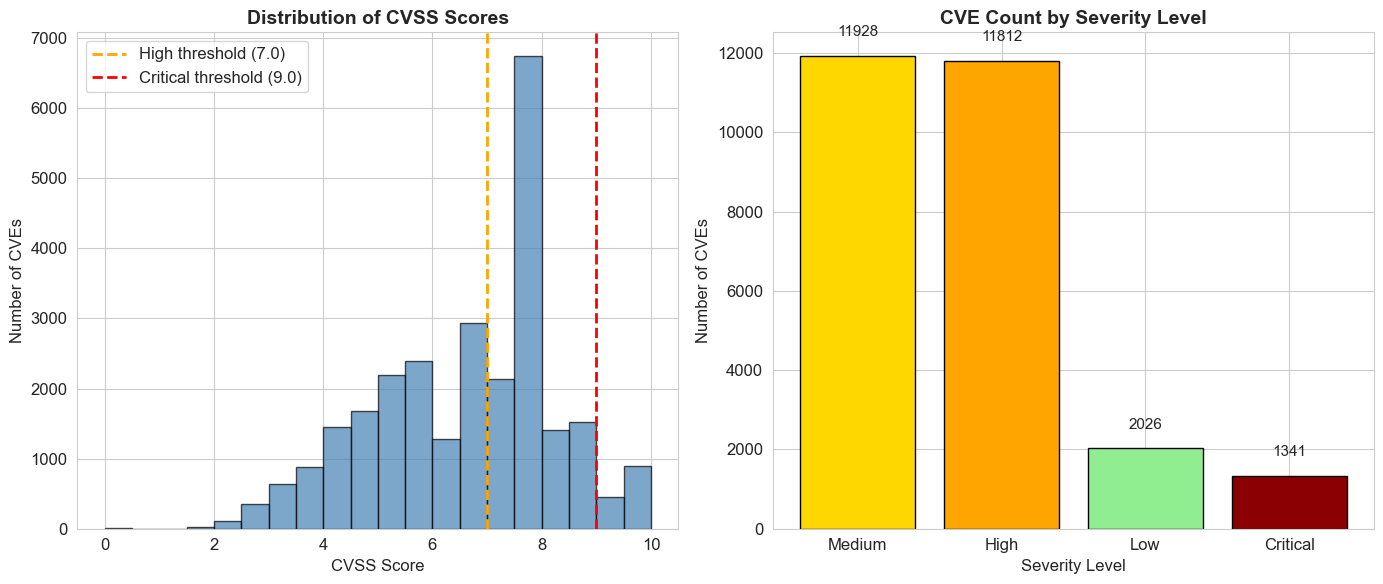

Saved: cvss_distribution.png

2. Top 10 CWE Types Pie Chart


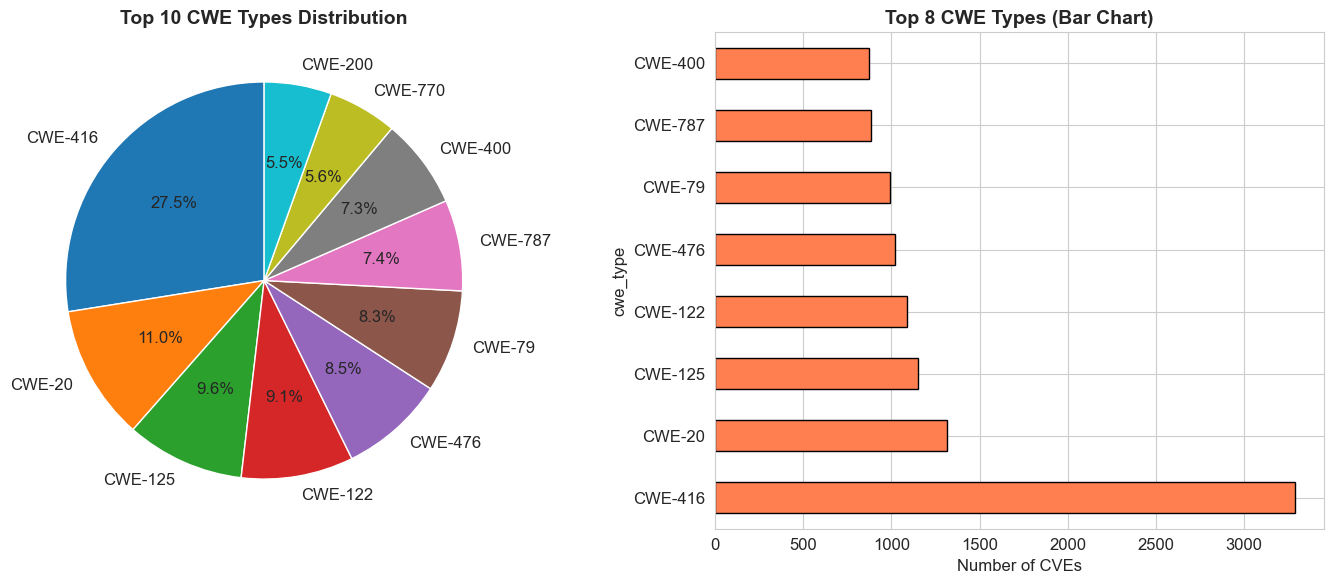

Saved: cwe_distribution.png

3. CVSS vs EPSS Scatter Plot


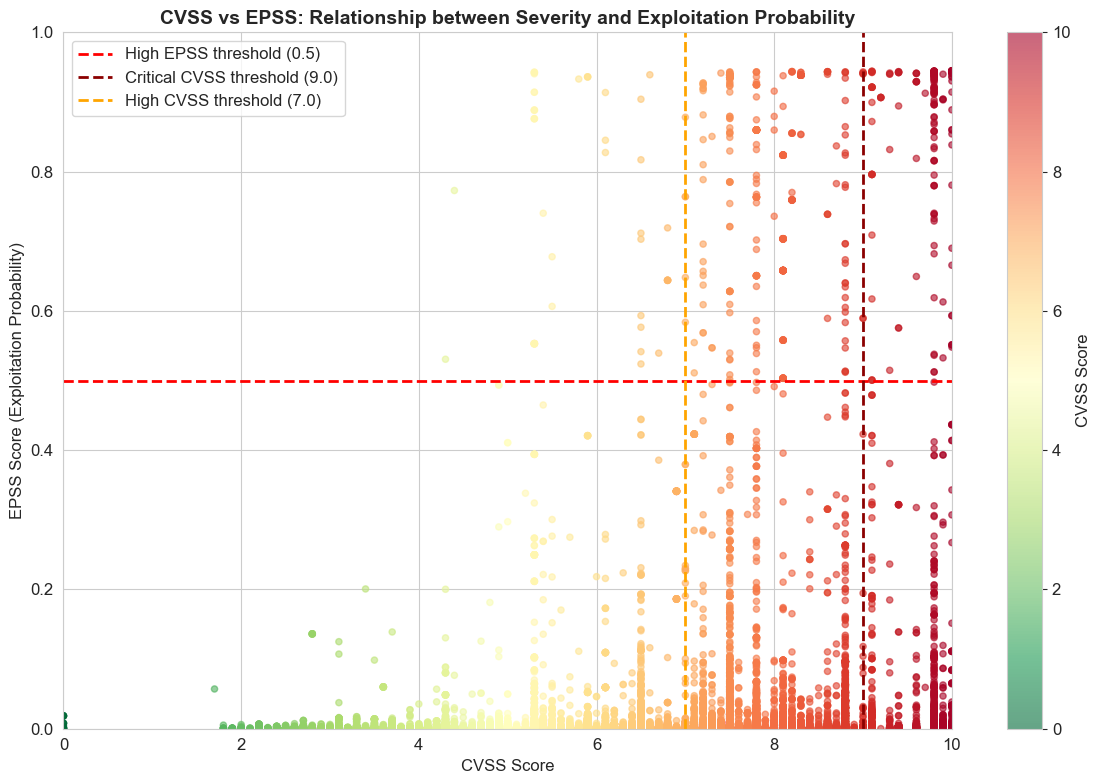

Saved: cvss_vs_epss_scatter.png

4. EPSS Score Distribution


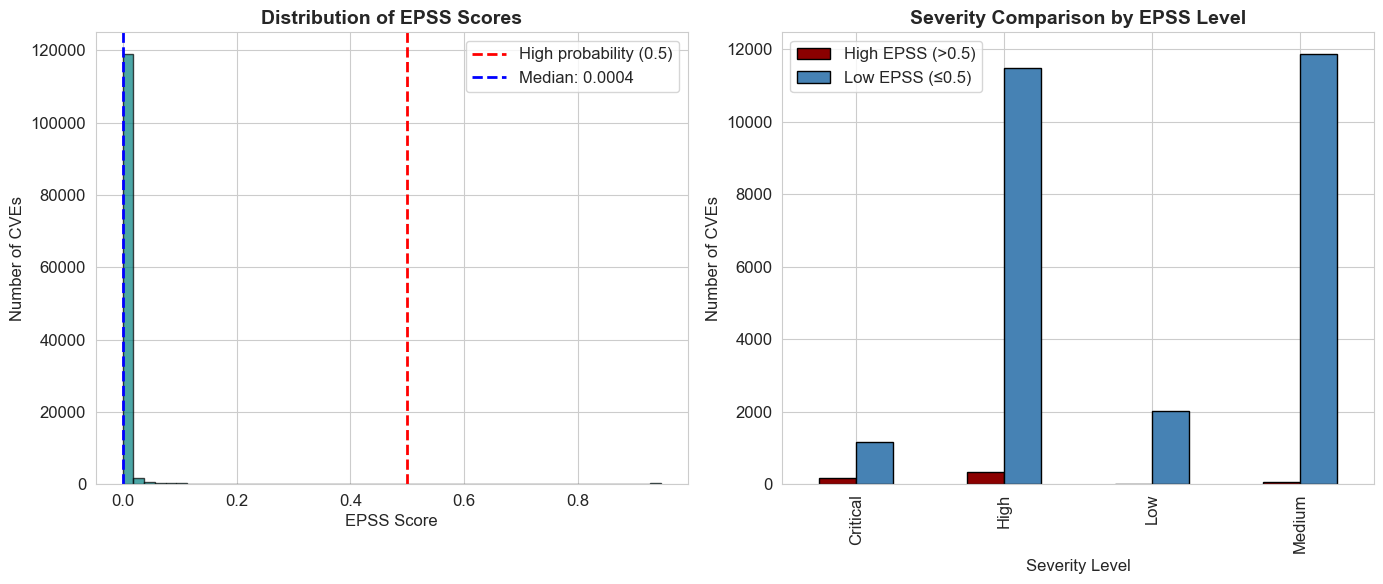

Saved: epss_distribution.png

5. Top 10 Most Affected Vendors


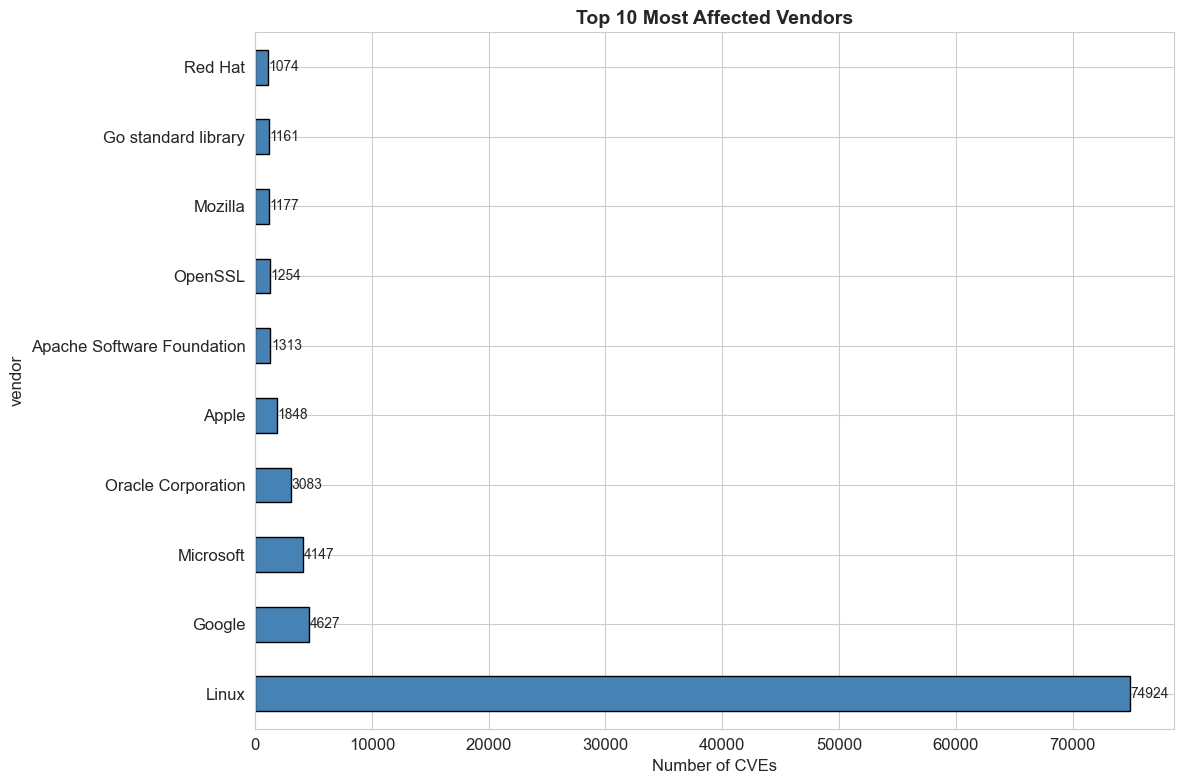

Saved: top_vendors.png

6. Top 10 Most Affected Products


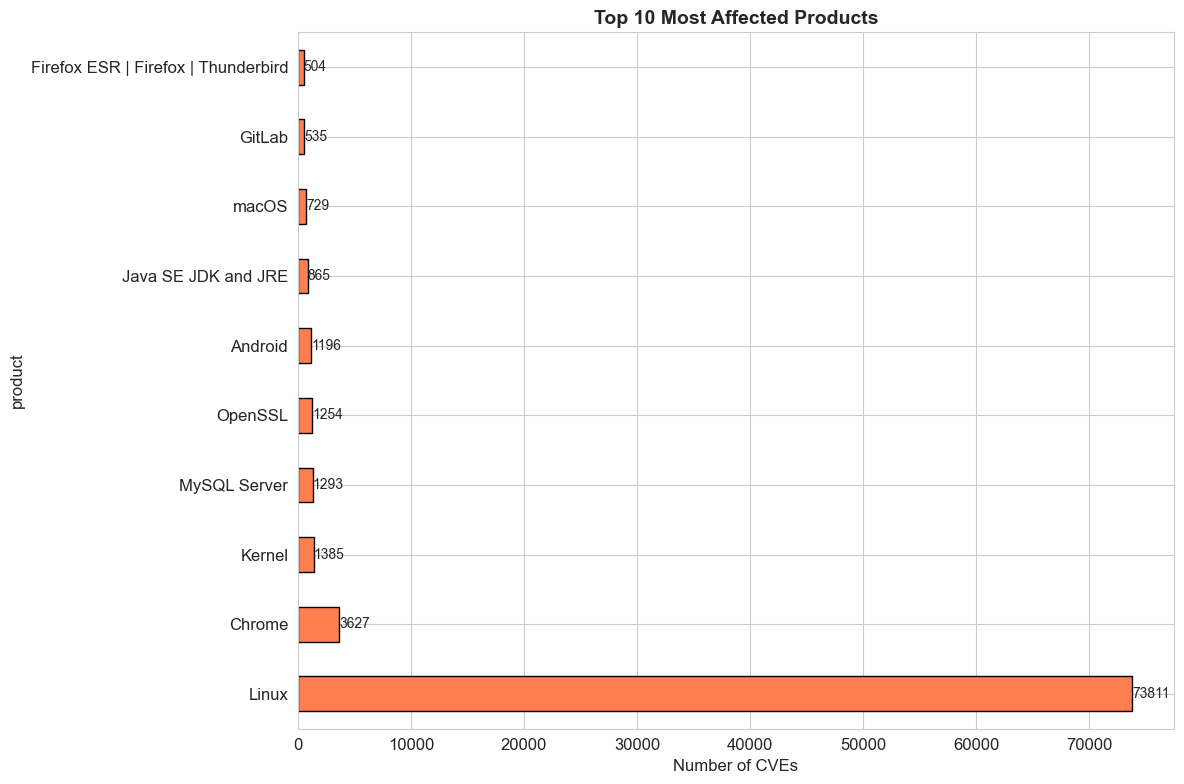

Saved: top_products.png

7. CVSS Boxplot by Top Vendors


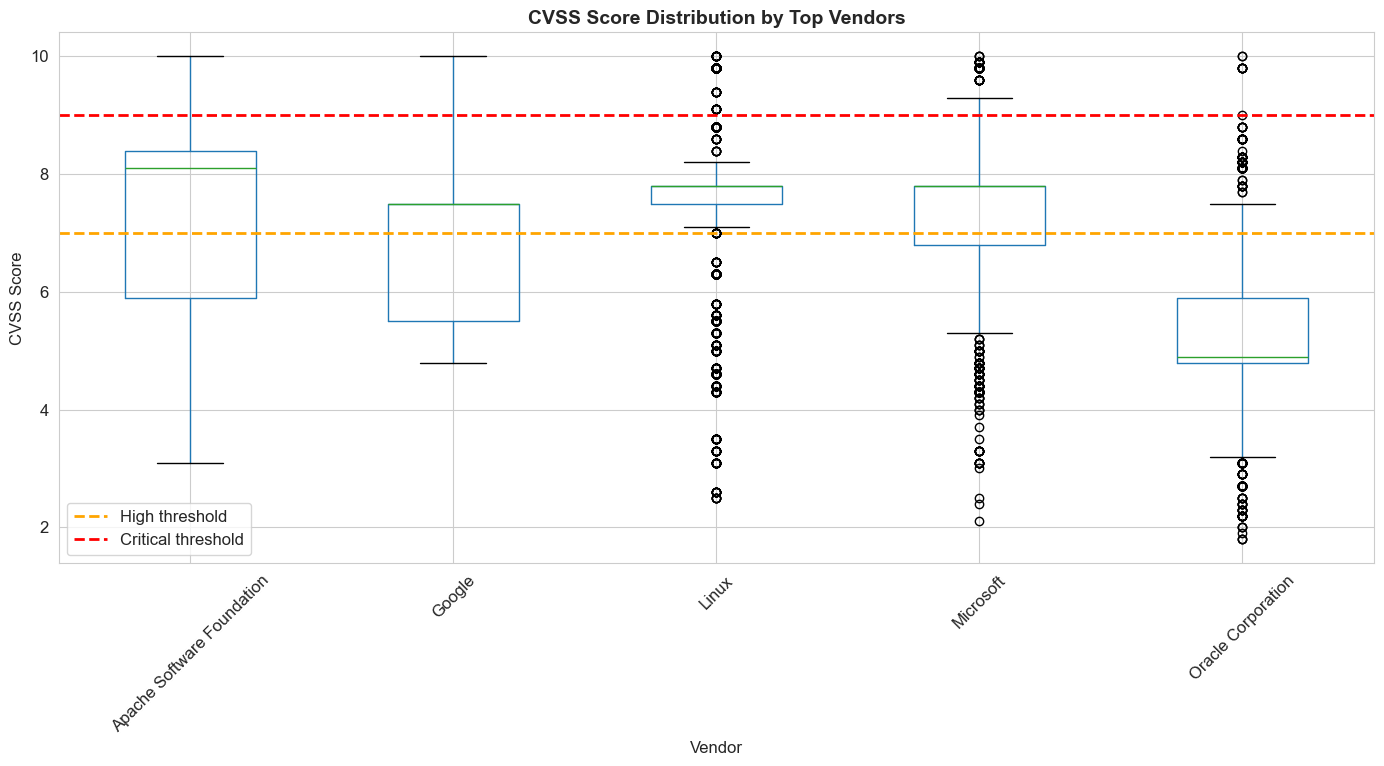

Saved: cvss_boxplot_by_vendor.png

8. Correlation Heatmap


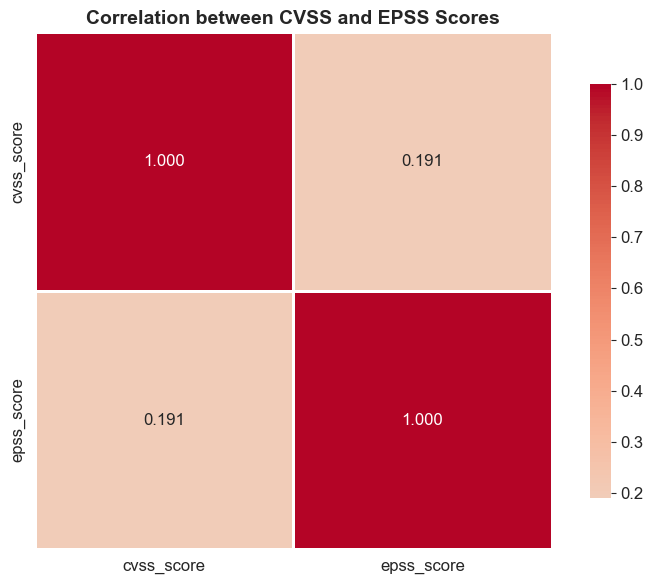

Correlation coefficient: 0.1910
Saved: correlation_heatmap.png

9. Bulletin Type Comparison (Avis vs Alertes)


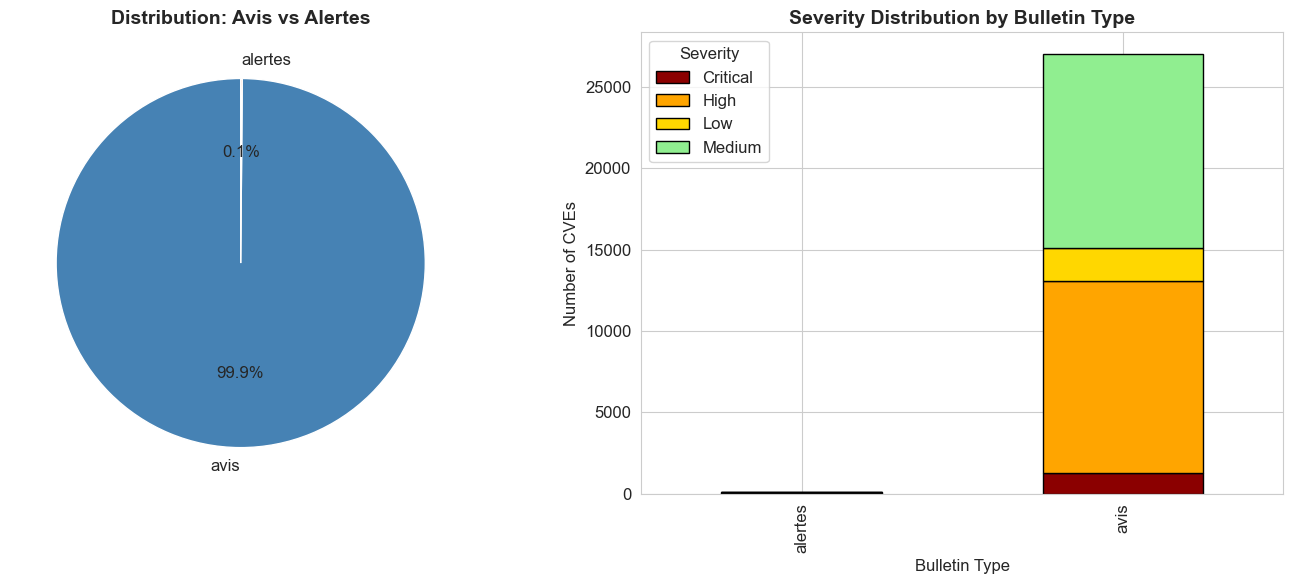

Saved: bulletin_type_comparison.png

10. Cumulative Vulnerabilities Over Time


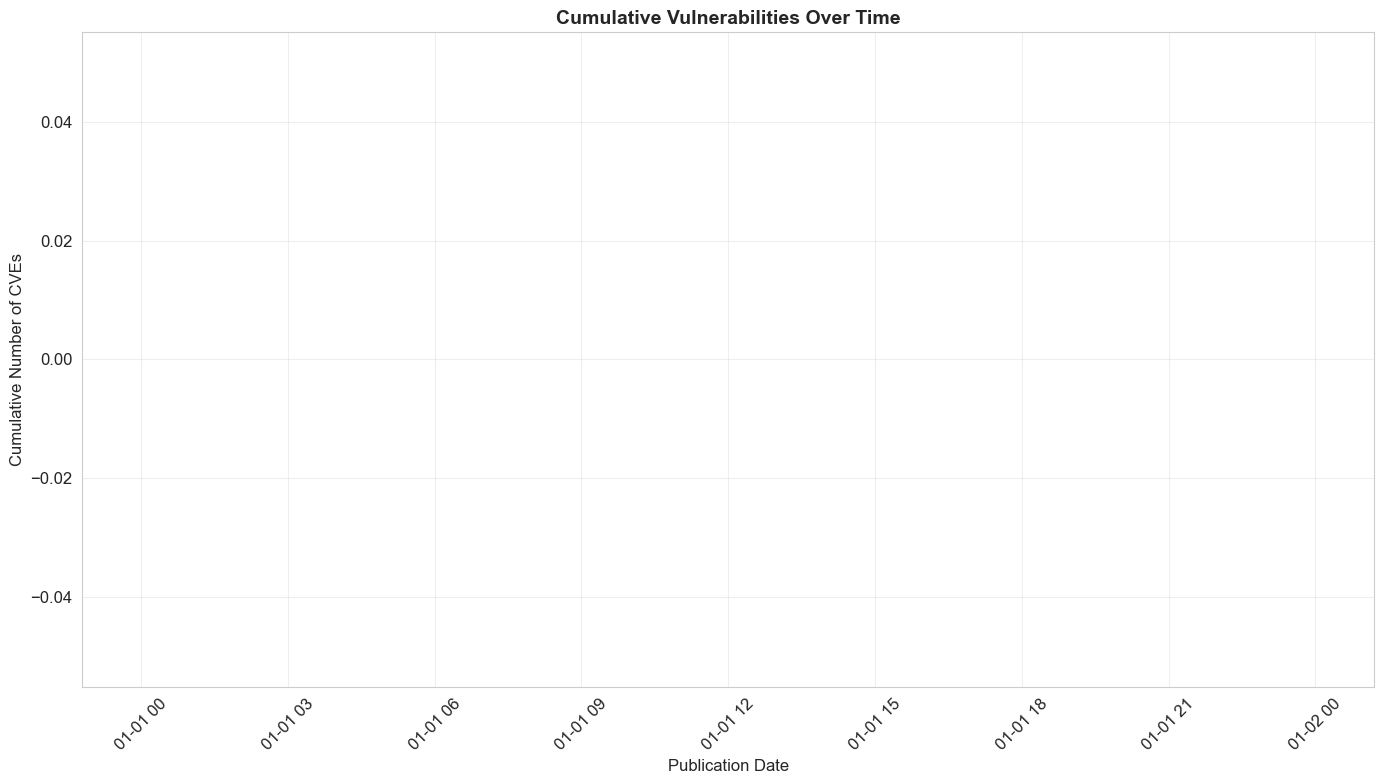

Saved: cumulative_vulns_over_time.png

11. Interactive Scatter Plot with Plotly
Saved: interactive_scatter.html (open in browser)

12. Statistical Summary
STATISTICAL SUMMARY

Total CVEs analyzed: 37,287
Total bulletin-CVE pairs: 125,936

CVSS Score Statistics:
  Mean: 6.57
  Median: 6.80
  Std: 1.66

EPSS Score Statistics:
  Mean: 0.0129
  Median: 0.0004
  CVEs with EPSS > 0.5: 1,288 (1.0%)

Critical CVEs (CVSS >= 9.0): 1,341 (4.9%)
High Risk CVEs (EPSS > 0.5 AND CVSS >= 7.0): 507

All visualizations saved to: ../outputs/plots/


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("STEP 5: Data Visualization and Analysis")
print("="*60)

df = pd.read_csv('../data/processed/consolidated_cve_data.csv')
df['cvss_score'] = pd.to_numeric(df['cvss_score'], errors='coerce')
df['epss_score'] = pd.to_numeric(df['epss_score'], errors='coerce')

print(f"Loaded {len(df)} rows, {df['cve_id'].nunique()} unique CVEs")
print(f"CVSS range: {df['cvss_score'].min():.1f} - {df['cvss_score'].max():.1f}")
print(f"EPSS range: {df['epss_score'].min():.4f} - {df['epss_score'].max():.4f}\n")

os.makedirs('../outputs/plots', exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("1. CVSS Score Distribution Histogram")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cvss_clean = df['cvss_score'].dropna()
axes[0].hist(cvss_clean, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('CVSS Score')
axes[0].set_ylabel('Number of CVEs')
axes[0].set_title('Distribution of CVSS Scores', fontsize=14, fontweight='bold')
axes[0].axvline(x=7.0, color='orange', linestyle='--', linewidth=2, label='High threshold (7.0)')
axes[0].axvline(x=9.0, color='red', linestyle='--', linewidth=2, label='Critical threshold (9.0)')
axes[0].legend()
severity_counts = df['base_severity'].value_counts()
colors_sev = {'Critical': 'darkred', 'High': 'orange', 'Medium': 'gold', 'Low': 'lightgreen', 'N/A': 'gray'}
severity_colors = [colors_sev.get(s, 'gray') for s in severity_counts.index]
axes[1].bar(severity_counts.index, severity_counts.values, color=severity_colors, edgecolor='black')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Number of CVEs')
axes[1].set_title('CVE Count by Severity Level', fontsize=14, fontweight='bold')
for i, (idx, val) in enumerate(zip(severity_counts.index, severity_counts.values)):
    axes[1].text(i, val + 500, str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/plots/cvss_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cvss_distribution.png\n")

print("2. Top 10 CWE Types Pie Chart")
cwe_counts = df[df['cwe_type'] != 'N/A']['cwe_type'].value_counts().head(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(cwe_counts.values, labels=cwe_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Top 10 CWE Types Distribution', fontsize=14, fontweight='bold')
cwe_counts.head(8).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Number of CVEs')
axes[1].set_title('Top 8 CWE Types (Bar Chart)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/cwe_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cwe_distribution.png\n")

print("3. CVSS vs EPSS Scatter Plot")
df_scatter = df.dropna(subset=['cvss_score', 'epss_score']).copy()
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(df_scatter['cvss_score'], df_scatter['epss_score'], 
                     c=df_scatter['cvss_score'], cmap='RdYlGn_r', alpha=0.6, s=20)
ax.set_xlabel('CVSS Score', fontsize=12)
ax.set_ylabel('EPSS Score (Exploitation Probability)', fontsize=12)
ax.set_title('CVSS vs EPSS: Relationship between Severity and Exploitation Probability', fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='High EPSS threshold (0.5)')
ax.axvline(x=9.0, color='darkred', linestyle='--', linewidth=2, label='Critical CVSS threshold (9.0)')
ax.axvline(x=7.0, color='orange', linestyle='--', linewidth=2, label='High CVSS threshold (7.0)')
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
plt.colorbar(scatter, label='CVSS Score')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/plots/cvss_vs_epss_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cvss_vs_epss_scatter.png\n")

print("4. EPSS Score Distribution")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
epss_clean = df['epss_score'].dropna()
axes[0].hist(epss_clean, bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('EPSS Score')
axes[0].set_ylabel('Number of CVEs')
axes[0].set_title('Distribution of EPSS Scores', fontsize=14, fontweight='bold')
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='High probability (0.5)')
axes[0].axvline(x=epss_clean.median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {epss_clean.median():.4f}')
axes[0].legend()
high_epss = df[df['epss_score'] > 0.5]['base_severity'].value_counts()
low_epss = df[df['epss_score'] <= 0.5]['base_severity'].value_counts()
epss_compare = pd.DataFrame({'High EPSS (>0.5)': high_epss, 'Low EPSS (≤0.5)': low_epss}).fillna(0)
epss_compare.plot(kind='bar', ax=axes[1], color=['darkred', 'steelblue'], edgecolor='black')
axes[1].set_xlabel('Severity Level')
axes[1].set_ylabel('Number of CVEs')
axes[1].set_title('Severity Comparison by EPSS Level', fontsize=14, fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('../outputs/plots/epss_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: epss_distribution.png\n")

print("5. Top 10 Most Affected Vendors")
vendor_counts = df[df['vendor'] != 'N/A']['vendor'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12, 8))
vendor_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of CVEs')
ax.set_title('Top 10 Most Affected Vendors', fontsize=14, fontweight='bold')
for i, (idx, val) in enumerate(zip(vendor_counts.index, vendor_counts.values)):
    ax.text(val + 50, i, str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/plots/top_vendors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: top_vendors.png\n")

print("6. Top 10 Most Affected Products")
product_counts = df[df['product'] != 'N/A']['product'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12, 8))
product_counts.plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Number of CVEs')
ax.set_title('Top 10 Most Affected Products', fontsize=14, fontweight='bold')
for i, (idx, val) in enumerate(zip(product_counts.index, product_counts.values)):
    ax.text(val + 10, i, str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/plots/top_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: top_products.png\n")

print("7. CVSS Boxplot by Top Vendors")
top_vendors = df[df['vendor'] != 'N/A']['vendor'].value_counts().head(8).index
df_top_vendors = df[df['vendor'].isin(top_vendors)].dropna(subset=['cvss_score'])
fig, ax = plt.subplots(figsize=(14, 8))
df_top_vendors.boxplot(column='cvss_score', by='vendor', ax=ax, rot=45)
ax.set_xlabel('Vendor', fontsize=12)
ax.set_ylabel('CVSS Score', fontsize=12)
ax.set_title('CVSS Score Distribution by Top Vendors', fontsize=14, fontweight='bold')
ax.axhline(y=7.0, color='orange', linestyle='--', linewidth=2, label='High threshold')
ax.axhline(y=9.0, color='red', linestyle='--', linewidth=2, label='Critical threshold')
ax.legend()
plt.suptitle('')
plt.tight_layout()
plt.savefig('../outputs/plots/cvss_boxplot_by_vendor.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cvss_boxplot_by_vendor.png\n")

print("8. Correlation Heatmap")
df_corr = df[['cvss_score', 'epss_score']].dropna()
correlation = df_corr.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True, 
            fmt='.3f', linewidths=1, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation between CVSS and EPSS Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Correlation coefficient: {correlation.iloc[0,1]:.4f}")
print("Saved: correlation_heatmap.png\n")

print("9. Bulletin Type Comparison (Avis vs Alertes)")
type_counts = df['bulletin_type'].value_counts()
type_severity = pd.crosstab(df['bulletin_type'], df['base_severity'])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
type_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=['steelblue', 'coral'], startangle=90)
axes[0].set_title('Distribution: Avis vs Alertes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')
type_severity.plot(kind='bar', ax=axes[1], stacked=True, color=['darkred', 'orange', 'gold', 'lightgreen', 'gray'], edgecolor='black')
axes[1].set_xlabel('Bulletin Type', fontsize=12)
axes[1].set_ylabel('Number of CVEs', fontsize=12)
axes[1].set_title('Severity Distribution by Bulletin Type', fontsize=14, fontweight='bold')
axes[1].legend(title='Severity')
plt.tight_layout()
plt.savefig('../outputs/plots/bulletin_type_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bulletin_type_comparison.png\n")

print("10. Cumulative Vulnerabilities Over Time")
df_time = df.copy()
df_time['publication_date'] = pd.to_datetime(df_time['publication_date'], errors='coerce')
df_time = df_time.dropna(subset=['publication_date'])
df_time = df_time.sort_values('publication_date')
df_time['cumulative_count'] = range(1, len(df_time) + 1)
fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(df_time['publication_date'], df_time['cumulative_count'], linewidth=2, color='steelblue')
ax.set_xlabel('Publication Date', fontsize=12)
ax.set_ylabel('Cumulative Number of CVEs', fontsize=12)
ax.set_title('Cumulative Vulnerabilities Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/plots/cumulative_vulns_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cumulative_vulns_over_time.png\n")

print("11. Interactive Scatter Plot with Plotly")
df_interactive = df.dropna(subset=['cvss_score', 'epss_score']).head(1000).copy()
fig = px.scatter(df_interactive, x='cvss_score', y='epss_score', color='base_severity',
                 hover_data=['cve_id', 'vendor', 'product', 'bulletin_id'],
                 title='Interactive: CVSS vs EPSS by Severity',
                 color_discrete_map={'Critical': 'darkred', 'High': 'orange', 
                                      'Medium': 'gold', 'Low': 'lightgreen', 'N/A': 'gray'})
fig.update_layout(width=1000, height=700)
fig.write_html('../outputs/plots/interactive_scatter.html')
print("Saved: interactive_scatter.html (open in browser)\n")

print("12. Statistical Summary")
print("="*50)
print("STATISTICAL SUMMARY")
print("="*50)
print(f"\nTotal CVEs analyzed: {df['cve_id'].nunique():,}")
print(f"Total bulletin-CVE pairs: {len(df):,}")
print(f"\nCVSS Score Statistics:")
print(f"  Mean: {df['cvss_score'].mean():.2f}")
print(f"  Median: {df['cvss_score'].median():.2f}")
print(f"  Std: {df['cvss_score'].std():.2f}")
print(f"\nEPSS Score Statistics:")
print(f"  Mean: {df['epss_score'].mean():.4f}")
print(f"  Median: {df['epss_score'].median():.4f}")
print(f"  CVEs with EPSS > 0.5: {(df['epss_score'] > 0.5).sum():,} ({(df['epss_score'] > 0.5).sum()/df['epss_score'].notna().sum()*100:.1f}%)")
print(f"\nCritical CVEs (CVSS >= 9.0): {(df['cvss_score'] >= 9.0).sum():,} ({((df['cvss_score'] >= 9.0).sum()/df['cvss_score'].notna().sum()*100):.1f}%)")
print(f"High Risk CVEs (EPSS > 0.5 AND CVSS >= 7.0): {((df['epss_score'] > 0.5) & (df['cvss_score'] >= 7.0)).sum():,}")

print("\n" + "="*50)
print("All visualizations saved to: ../outputs/plots/")
print("="*50)

STEP 6: Machine Learning Models
Data for ML: 27091 rows

PART 1: SUPERVISED LEARNING - Predict Severity from EPSS

Accuracy: 0.5344 (53.44%)

Classification Report:
              precision    recall  f1-score   support

    Critical       0.80      0.07      0.13       401
        High       0.61      0.38      0.47      3542
         Low       0.00      0.00      0.00       608
      Medium       0.50      0.83      0.63      3577

    accuracy                           0.53      8128
   macro avg       0.48      0.32      0.31      8128
weighted avg       0.53      0.53      0.49      8128



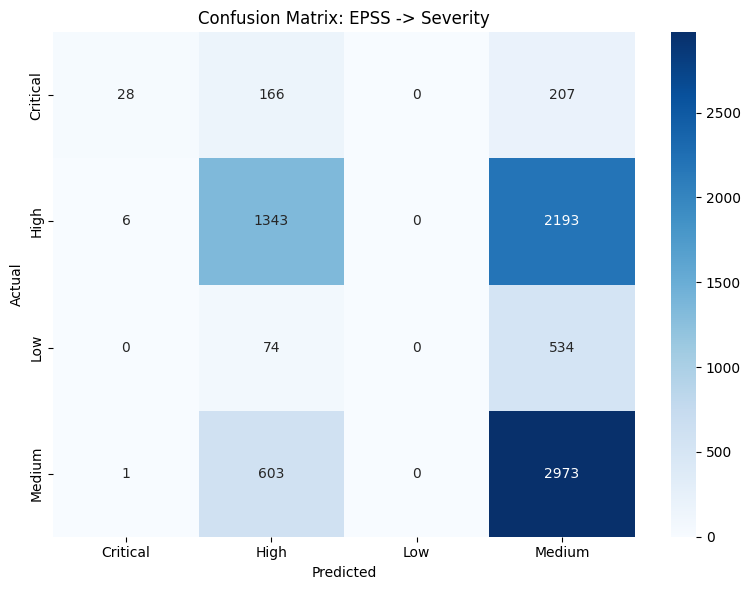


PART 2: SUPERVISED LEARNING - Predict EPSS from CVSS

Mean Squared Error: 0.012756
R² Score: 0.0595 (5.95%)


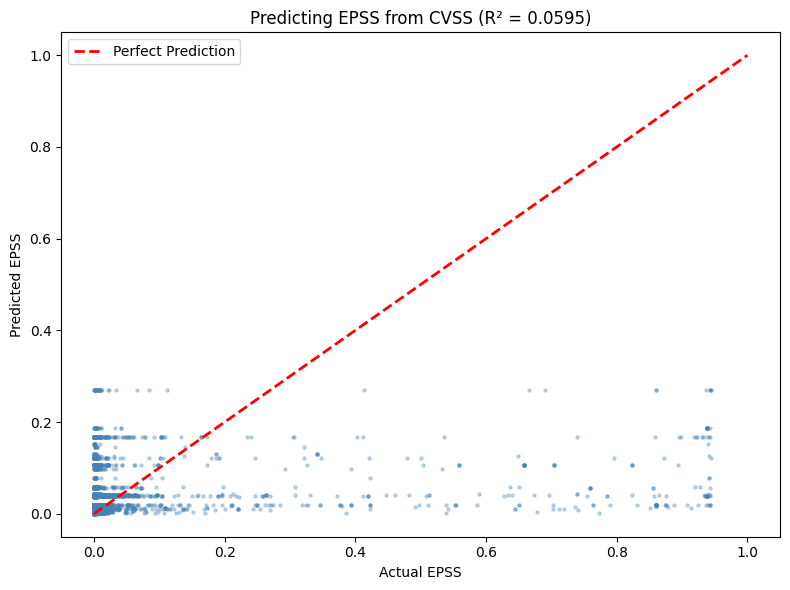


PART 3: UNSUPERVISED LEARNING - KMeans Clustering


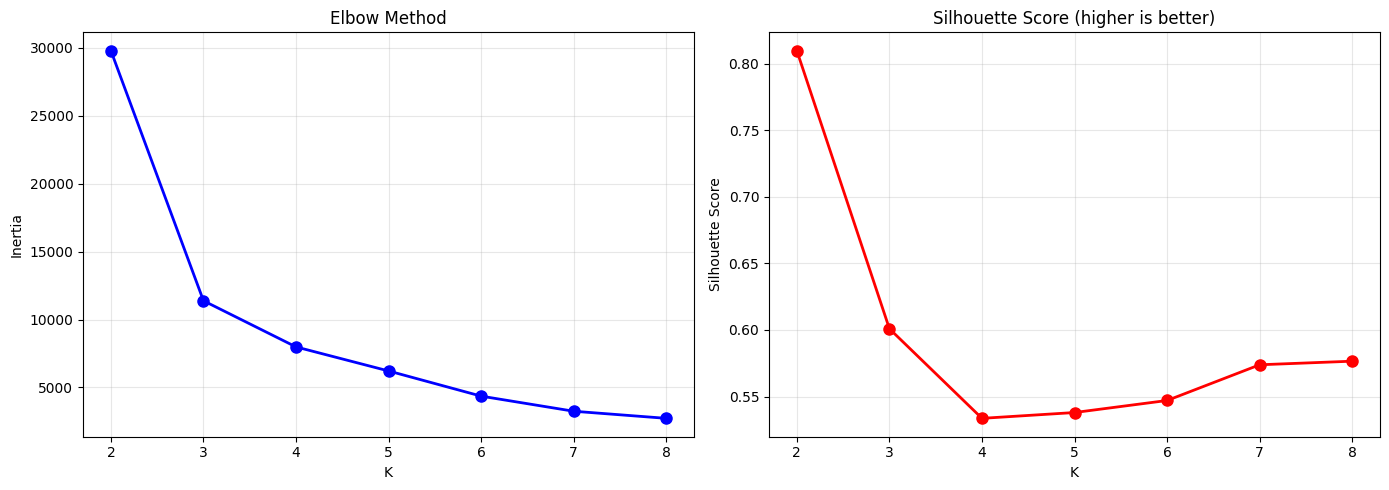


Best K by silhouette score: 2
Selected K for business requirements: 4
Reason: Balance between statistical performance and business interpretability (Critical/High/Medium/Low risk levels)

Cluster Distribution (K=4):
  Cluster 0: 9,002 CVEs (33.2%)
  Cluster 1: 646 CVEs (2.4%)
  Cluster 2: 12,084 CVEs (44.6%)
  Cluster 3: 5,359 CVEs (19.8%)

Cluster Characteristics:
         cvss_score  epss_score
cluster                        
0            6.0306      0.0056
1            8.2429      0.7505
2            7.9776      0.0133
3            4.0776      0.0027

Cluster Interpretation:
  Cluster 0: LOW PRIORITY: Can be deferred (CVSS=6.03, EPSS=0.0056)
  Cluster 1: CRITICAL PRIORITY: Immediate action required (CVSS=8.24, EPSS=0.7505)
  Cluster 2: SEVERE BUT SAFE: Schedule for next patch cycle (CVSS=7.98, EPSS=0.0133)
  Cluster 3: LOW PRIORITY: Can be deferred (CVSS=4.08, EPSS=0.0027)


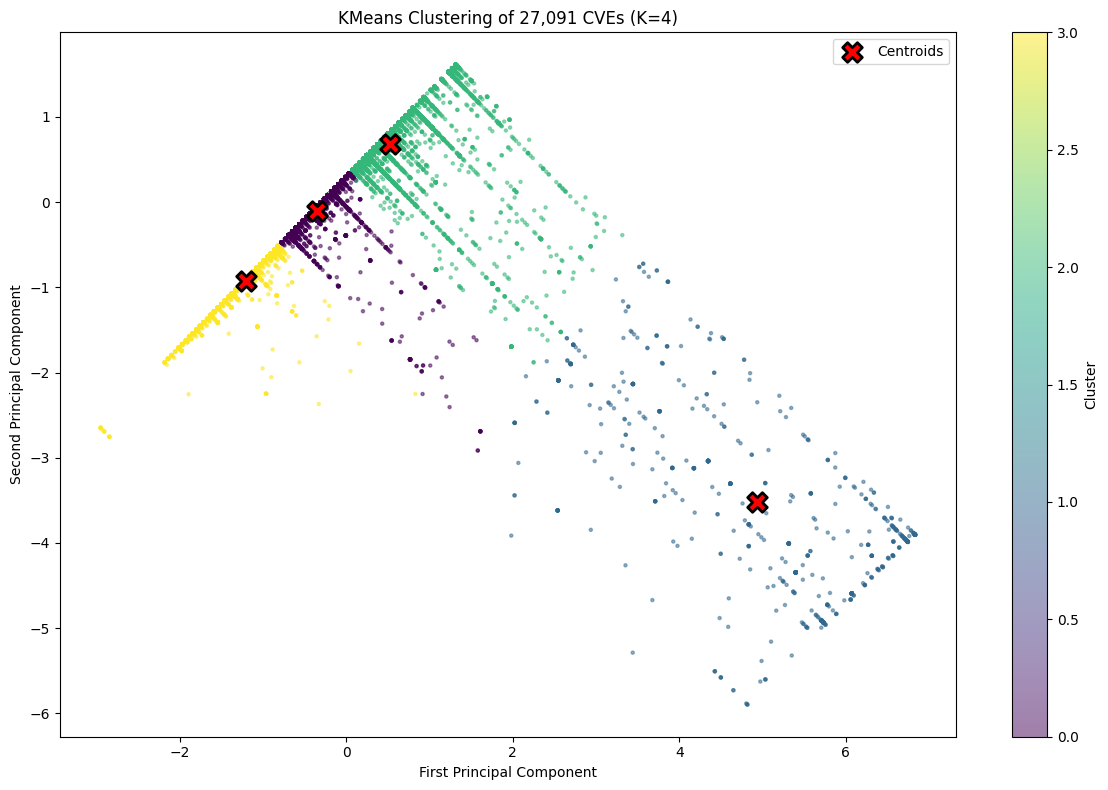


MODEL VALIDATION SUMMARY

Random Forest Classifier - 5-fold CV: 0.5049 (+/- 0.0666)
Random Forest Regressor - R²: 0.0595
KMeans Clustering - Silhouette Score for K=4: 0.5336

All outputs saved to: ../outputs/plots/


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error, r2_score, silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("STEP 6: Machine Learning Models")
print("="*60)

df = pd.read_csv('../data/processed/consolidated_cve_data.csv')
df['cvss_score'] = pd.to_numeric(df['cvss_score'], errors='coerce')
df['epss_score'] = pd.to_numeric(df['epss_score'], errors='coerce')

df_ml = df.dropna(subset=['cvss_score', 'epss_score', 'base_severity']).copy()
df_ml = df_ml[df_ml['base_severity'] != 'N/A']
print(f"Data for ML: {len(df_ml)} rows")

print("\n" + "="*60)
print("PART 1: SUPERVISED LEARNING - Predict Severity from EPSS")
print("="*60)

features = ['epss_score']
X = df_ml[features].values
y = df_ml['base_severity'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: EPSS -> Severity')
plt.tight_layout()
plt.savefig('../outputs/plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("PART 2: SUPERVISED LEARNING - Predict EPSS from CVSS")
print("="*60)

X_reg = df_ml[['cvss_score']].values
y_reg = df_ml['epss_score'].values

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)

y_pred_r = rf_reg.predict(X_test_r)
mse = mean_squared_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print(f"\nMean Squared Error: {mse:.6f}")
print(f"R² Score: {r2:.4f} ({r2*100:.2f}%)")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.3, s=5, color='steelblue')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual EPSS')
plt.ylabel('Predicted EPSS')
plt.title(f'Predicting EPSS from CVSS (R² = {r2:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/epss_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("PART 3: UNSUPERVISED LEARNING - KMeans Clustering")
print("="*60)

X_cluster = df_ml[['cvss_score', 'epss_score']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher is better)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/optimal_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_silhouette = K_range[np.argmax(silhouette_scores)]
print(f"\nBest K by silhouette score: {best_k_silhouette}")

optimal_k = 4
print(f"Selected K for business requirements: {optimal_k}")
print("Reason: Balance between statistical performance and business interpretability (Critical/High/Medium/Low risk levels)")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df_ml['cluster'] = cluster_labels

print(f"\nCluster Distribution (K={optimal_k}):")
for i in range(optimal_k):
    count = (df_ml['cluster'] == i).sum()
    print(f"  Cluster {i}: {count:,} CVEs ({count/len(df_ml)*100:.1f}%)")

cluster_summary = df_ml.groupby('cluster').agg({
    'cvss_score': 'mean',
    'epss_score': 'mean'
}).round(4)
print("\nCluster Characteristics:")
print(cluster_summary)

print("\nCluster Interpretation:")
for i in range(optimal_k):
    mean_cvss = cluster_summary.loc[i, 'cvss_score']
    mean_epss = cluster_summary.loc[i, 'epss_score']
    
    if mean_cvss >= 7.0 and mean_epss >= 0.5:
        label = "CRITICAL PRIORITY: Immediate action required"
    elif mean_cvss >= 7.0 and mean_epss < 0.5:
        label = "SEVERE BUT SAFE: Schedule for next patch cycle"
    elif mean_cvss < 7.0 and mean_epss >= 0.5:
        label = "SNEAKY THREAT: Investigate why highly exploited"
    else:
        label = "LOW PRIORITY: Can be deferred"
    
    print(f"  Cluster {i}: {label} (CVSS={mean_cvss:.2f}, EPSS={mean_epss:.4f})")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.5, s=5)
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'KMeans Clustering of {len(df_ml):,} CVEs (K={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/clustering_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("MODEL VALIDATION SUMMARY")
print("="*60)

cv_scores = cross_val_score(rf_clf, X, y_encoded, cv=5)
print(f"\nRandom Forest Classifier - 5-fold CV: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print(f"Random Forest Regressor - R²: {r2:.4f}")
print(f"KMeans Clustering - Silhouette Score for K={optimal_k}: {silhouette_scores[optimal_k-2]:.4f}")

print("\n" + "="*60)
print("All outputs saved to: ../outputs/plots/")
print("="*60)

In [6]:
import pandas as pd
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from datetime import datetime
import os

print("="*60)
print("STEP 7: Alert Generation and Email Notifications")
print("="*60)

df = pd.read_csv('../data/processed/consolidated_cve_data.csv')
df['cvss_score'] = pd.to_numeric(df['cvss_score'], errors='coerce')
df['epss_score'] = pd.to_numeric(df['epss_score'], errors='coerce')

print(f"Loaded {len(df)} rows for alert analysis")

print("\n" + "="*60)
print("PART 1: Define Alert Rules")
print("="*60)

RULES = {
    'critical_cvss_high_epss': {
        'condition': (df['cvss_score'] >= 9.0) & (df['epss_score'] >= 0.7),
        'name': 'CRITICAL: High Severity + High Exploitability',
        'priority': 1,
        'color': '🔴'
    },
    'critical_cvss_only': {
        'condition': (df['cvss_score'] >= 9.0) & (df['epss_score'] < 0.7),
        'name': 'HIGH: Critical Severity but Low Exploitability',
        'priority': 2,
        'color': '🟠'
    },
    'high_epss_only': {
        'condition': (df['cvss_score'] < 9.0) & (df['cvss_score'] >= 7.0) & (df['epss_score'] >= 0.7),
        'name': 'WARNING: High Exploitability with High Severity',
        'priority': 3,
        'color': '🟡'
    },
    'targeted_product': {
        'condition': (df['cvss_score'] >= 7.0) & (df['product'].str.contains('Windows|Linux|Apache|Chrome', case=False, na=False)),
        'name': 'TARGETED: Popular Product at Risk',
        'priority': 4,
        'color': '🟢'
    }
}

for rule_key, rule in RULES.items():
    count = rule['condition'].sum()
    print(f"{rule['color']} {rule['name']}: {count} alerts")

print("\n" + "="*60)
print("PART 2: Generate Alert Messages")
print("="*60)

def generate_alert_email(cve_data, rule_name):
    subject = f"[SECURITY ALERT] {rule_name} - {cve_data['cve_id']}"
    
    body = f"""
SECURITY ALERT NOTIFICATION
{'='*50}

Alert Type: {rule_name}
Priority: Emergency
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

VULNERABILITY DETAILS:
{'='*30}
CVE ID: {cve_data['cve_id']}
CVSS Score: {cve_data['cvss_score']} ({cve_data['base_severity']})
EPSS Score: {cve_data['epss_score']:.4f} (Exploitation Probability)

AFFECTED PRODUCTS:
{'='*30}
Vendor: {cve_data['vendor']}
Product: {cve_data['product']}
Affected Versions: {cve_data['affected_versions']}

DESCRIPTION:
{'='*30}
{cve_data['cve_description'][:500] if pd.notna(cve_data['cve_description']) else 'No description available'}

RECOMMENDED ACTIONS:
{'='*30}
1. Immediately identify affected systems
2. Apply vendor patches as soon as available
3. Implement mitigation measures if patch unavailable
4. Monitor for suspicious activity

REFERENCES:
{'='*30}
ANSSI Bulletin: {cve_data['bulletin_link']}
MITRE Entry: https://cve.mitre.org/cgi-bin/cvename.cgi?name={cve_data['cve_id']}

This is an automated security alert. Please take appropriate action.
"""
    return subject, body

alerts = []
for rule_key, rule in RULES.items():
    triggered = df[rule['condition']].copy()
    for idx, row in triggered.head(10).iterrows():
        subject, body = generate_alert_email(row, rule['name'])
        alerts.append({
            'cve_id': row['cve_id'],
            'rule': rule['name'],
            'priority': rule['priority'],
            'subject': subject,
            'body': body,
            'vendor': row['vendor'],
            'product': row['product']
        })

print(f"Generated {len(alerts)} alert messages (showing first 10 per rule)")

print("\n" + "="*60)
print("PART 3: Display Sample Alerts")
print("="*60)

for i, alert in enumerate(alerts[:5]):
    print(f"\n{'='*40}")
    print(f"ALERT #{i+1}: {alert['rule']}")
    print(f"{'='*40}")
    print(f"CVE: {alert['cve_id']}")
    print(f"Vendor: {alert['vendor']}")
    print(f"Product: {alert['product']}")
    print(f"\nSubject: {alert['subject']}")
    print(f"\nBody Preview: {alert['body'][:300]}...")
    print(f"{'='*40}")

print("\n" + "="*60)
print("PART 4: Export Alerts to CSV")
print("="*60)

alerts_df = pd.DataFrame(alerts)
alerts_df.to_csv('../outputs/generated_alerts.csv', index=False, encoding='utf-8')
print(f"Saved {len(alerts_df)} alerts to: ../outputs/generated_alerts.csv")

print("\n" + "="*60)
print("PART 5: Email Configuration (Optional - Disabled by Default)")
print("="*60)

EMAIL_ENABLED = False

if EMAIL_ENABLED:
    SMTP_SERVER = "smtp.gmail.com"
    SMTP_PORT = 587
    SENDER_EMAIL = "your_email@gmail.com"
    SENDER_PASSWORD = "your_app_password"
    RECIPIENT_EMAIL = "security_team@company.com"
    
    def send_email(recipient, subject, body):
        try:
            msg = MIMEMultipart()
            msg['From'] = SENDER_EMAIL
            msg['To'] = recipient
            msg['Subject'] = subject
            msg.attach(MIMEText(body, 'plain'))
            
            server = smtplib.SMTP(SMTP_SERVER, SMTP_PORT)
            server.starttls()
            server.login(SENDER_EMAIL, SENDER_PASSWORD)
            server.send_message(msg)
            server.quit()
            print(f"✅ Email sent to {recipient}")
            return True
        except Exception as e:
            print(f"❌ Failed to send email: {e}")
            return False
    
    print("\nSending test email to security team...")
    test_subject = "[TEST] Security Alert System Online"
    test_body = f"Security alert system is operational. Generated {len(alerts)} alerts at {datetime.now()}"
    send_email(RECIPIENT_EMAIL, test_subject, test_body)
    
    print("\nSending priority alerts...")
    high_priority_alerts = [a for a in alerts if a['priority'] <= 2]
    for alert in high_priority_alerts[:5]:
        send_email(RECIPIENT_EMAIL, alert['subject'], alert['body'])
else:
    print("\n📧 Email sending is DISABLED.")
    print("   To enable emails:")
    print("   1. Set EMAIL_ENABLED = True")
    print("   2. Configure SMTP_SERVER, SENDER_EMAIL, SENDER_PASSWORD")
    print("   3. Use Gmail App Password (not regular password)")
    print("\n   Email content has been generated and saved to CSV.")
    print("   This satisfies the requirement: 'the creation of the email subject and body is important'")

print("\n" + "="*60)
print("ALERT SUMMARY REPORT")
print("="*60)

print(f"\nTotal alerts generated: {len(alerts)}")
print(f"Alert distribution by rule:")
rule_counts = alerts_df['rule'].value_counts()
for rule, count in rule_counts.items():
    print(f"  {rule}: {count}")

print(f"\nTop affected vendors in alerts:")
vendor_counts = alerts_df['vendor'].value_counts().head(5)
for vendor, count in vendor_counts.items():
    print(f"  {vendor}: {count}")

print(f"\nTop affected products in alerts:")
product_counts = alerts_df['product'].value_counts().head(5)
for product, count in product_counts.items():
    print(f"  {product}: {count}")

print("\n" + "="*60)
print("STEP 7 COMPLETED")
print("="*60)
print("\nOutput files generated:")
print("  - ../outputs/generated_alerts.csv (Alert data)")
print("  - Email content (displayed above)")


STEP 7: Alert Generation and Email Notifications
Loaded 125936 rows for alert analysis

PART 1: Define Alert Rules
🔴 CRITICAL: High Severity + High Exploitability: 154 alerts
🟠 HIGH: Critical Severity but Low Exploitability: 1184 alerts
🟡 WARNING: High Exploitability with High Severity: 225 alerts
🟢 TARGETED: Popular Product at Risk: 4428 alerts

PART 2: Generate Alert Messages
Generated 40 alert messages (showing first 10 per rule)

PART 3: Display Sample Alerts

ALERT #1: CRITICAL: High Severity + High Exploitability
CVE: CVE-2020-14871
Vendor: Oracle Corporation
Product: Solaris Operating System

Subject: [SECURITY ALERT] CRITICAL: High Severity + High Exploitability - CVE-2020-14871

Body Preview: 
SECURITY ALERT NOTIFICATION

Alert Type: CRITICAL: High Severity + High Exploitability
Priority: Emergency
Generated: 2026-06-13 17:34:21

VULNERABILITY DETAILS:
CVE ID: CVE-2020-14871
CVSS Score: 10.0 (Critical)
EPSS...

ALERT #2: CRITICAL: High Severity + High Exploitability
CVE: CVE-2